In [1]:
!nvidia-smi

Tue Jul 14 16:12:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:01:00.0 Off |                    0 |
| N/A   31C    P0             54W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
import numpy as np
import xarray as xr
import pickle
import glob
import warnings
from pathlib import Path, PureWindowsPath
import re

import cedalion
import cedalion.sigproc.motion as motion_correct
import cedalion.sigproc.quality as quality
import cedalion.sigproc.physio as physio
import cedalion.dot as dot
import cedalion.nirs as nirs
import cedalion.vis.anatomy
from cedalion.io.forward_model import load_Adot
import cedalion.dot.image_recon as dot_image_recon

from cedalion import units
import pandas as pd

warnings.filterwarnings("ignore")

In [3]:
def get_bad_ch_mask(int_data, ch_preproc) -> list:
    # Saturated and Dark Channels
    dark_sat_thresh = [1e-3, 0.84]
    amp_threshs_sat = [0., dark_sat_thresh[1]]
    amp_threshs_low = [dark_sat_thresh[0], 1]
    _, amp_mask_sat = quality.mean_amp(int_data, amp_threshs_sat)
    _, amp_mask_low = quality.mean_amp(int_data, amp_threshs_low)
    _, snr_mask = quality.snr(int_data, 10)
    amp_mask=amp_mask_sat & amp_mask_low

    _, list_bad_ch = quality.prune_ch(int_data, [amp_mask, snr_mask], "all")
   
    return list_bad_ch

# Theekshana
# def get_bad_ch_mask(int_data: xr.DataArray, ch_preproc: dict) -> list:
#     # SCI and PSP Mask    
#     sci, sci_mask = quality.sci(int_data, ch_preproc['window_len'], ch_preproc['sci_thresh'])
#     psp, psp_mask = quality.psp(int_data, ch_preproc['window_len'], ch_preproc['psp_thresh'])

#     sci_psp_mask=sci_mask & psp_mask
#     perc_time_clean = sci_psp_mask.sum(dim="time") / len(sci.time)

#     scipsp_bad_ch=[]
#     for ch in perc_time_clean.channel.values:
#         if perc_time_clean.sel(channel=ch).values < ch_preproc['perc_time_clean']: # dont make the mistake of using the inv condition >:| 
#             scipsp_bad_ch.append(ch)

#     sum_bad_ch = scipsp_bad_ch
#     list_bad_ch = sorted(list(set(sum_bad_ch)))  # remove duplicates

#     print("Flagged Channels : ",len(list_bad_ch), '/', len(int_data.channel))
#     print("Percentage: ", int(len(list_bad_ch) / len(int_data.channel) * 100), '%')
    
#     return list_bad_ch

In [4]:
def standardize_trial_types(DATASET_NAME: str, file: str, stim: pd.DataFrame, rec):
    
    if DATASET_NAME == "FreshMotor":
        # map trial types to left or right depending on the name of the file
        m = re.search(r'(?i)(left|right)', file)

        # rename from MOTOR to left/right
        rec.stim.trial_type = m.group(1).lower()
        # rec.stim = stim
    
    elif DATASET_NAME == "BallSqueezingHD":
        mapping = {
            "Right": "right", # BallSqueezingHD
            "Left": "left",   # BallSqueezingHD
        }
        rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)
        
    elif DATASET_NAME == "BS_Laura":
        rec.stim = stim  
        
    elif DATASET_NAME == "Electrical_Thermal":
        mapping = {
            "1": "WordCongruent" ,
            "2": "WordIncongruent",
        }
        rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)
        
    elif DATASET_NAME in ["vfc_hd", "Anderson_sparse"]:
        mapping = {
            "1": "WordCongruent" ,
            "2": "WordIncongruent",
        }
        
        rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)
    
    rec.stim.sort_values(by="onset", ignore_index=True, inplace=True)

    # attach/update stim info to rec
    # rec.stim = stim

    return stim, rec

# def standardize_trial_types(DATASET_NAME: str, file: str, rec):
    
#     if DATASET_NAME == "FreshMotor":
#         # map trial types to left or right depending on the name of the file
#         m = re.search(r'(?i)(left|right)', file)

#         # rename from MOTOR to left/right
#         rec.stim.trial_type = m.group(1).lower()
    
#     else:
#         mapping = {
#             "Right": "right", # BallSqueezingHD
#             "Left": "left",   # BallSqueezingHD
#             "ElectricalVAS7": "right", # TODO: Electrical_Thermal
#             "ElectricalVAS3": "left",  # TODO: Electrical_Thermal
#         }
#         rec.stim["trial_type"] = rec.stim["trial_type"].replace(mapping)

#     return rec


In [5]:
 # "full", "subset_2" for spatial_sampling, "motor" for motor_sampling

# subset_type = ""


In [6]:
# augmentation_strategy = "imageRecon_params"
augmentation_strategy = "base"

mixed_sparse = False
if mixed_sparse:
    n_chs = 50
    subset_type = f"motor_{n_chs}chs" # for sparsified version of Laura
    sparsified_data_path = f'datasets/pre_processed/BS_Laura/channel_subset_BS_Laura_k=2_c3c4k=51_dist4.5_{n_chs}chs.npy'
else:
    subset_type = "full"

base_path = "/home/orabe/fNIRS_sparseToDense/"

# Available datasets:
DATASET_NAME = "BallSqueezingHD_modified"
# DATASET_NAME = "FreshMotor"
# DATASET_NAME = "BS_Laura"
# DATASET_NAME = "ElectricalThermal"
# DATASET_NAME = "vfc_hd"
# DATASET_NAME = "Anderson_sparse"

raw_path = Path(f'datasets/raw/{DATASET_NAME}')

pre_processed_path = Path(f'datasets/pre_processed/{augmentation_strategy}/{DATASET_NAME}/{subset_type}')

pre_processed_path.mkdir(parents=True, exist_ok=True)
pre_processed_path

# # For Laura channel space subset 2
# pre_processed_path = Path(f'datasets/pre_processed/imageRecon_params/BS_Laura/subset_2/motor_100chs')
# pre_processed_path.mkdir(parents=True, exist_ok=True)
# pre_processed_path


PosixPath('datasets/pre_processed/base/BallSqueezingHD_modified/full')

In [7]:
if DATASET_NAME == "BallSqueezingHD_modified":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"

elif DATASET_NAME == "BS_Laura":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"
    
elif DATASET_NAME == "Electrical_Thermal":
    raw_dir = f"{raw_path}/sub-*/ses-*/nirs/sub-*_ses-*_task-Electrical*_nirs.snirf"
    # TODO: exclude subjects without txt files for landmarks coords
    
elif DATASET_NAME == "FreshMotor":
    duration = "*" # * to include both 2s and 3s
    raw_dir = f"{raw_path}/sub-*/ses-*{duration}/nirs/sub-*_ses-*{duration}_task-FRESHMOTOR_nirs.snirf"
elif DATASET_NAME == "vfc_hd":
    # "datasets/raw/vfc_hd/sub-01/nirs/sub-01_ses-02_task-WordStroop_run-01_nirs.snirf"
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"
elif DATASET_NAME == "Anderson_sparse":
    # raw_dir = f"{raw_path}/sub-*/ses-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*_ses-*_task-WordStroop_run-*_nirs.snirf"    

else:
    raise ValueError("Unknown dataset name")

files = glob.glob(raw_dir)

# TODO: to be confirmed
# remove non-BS files for Laura's dataset to avoid errors
if DATASET_NAME == "BS_Laura":
    files = [p for p in files if "BS" in os.path.basename(p)]
    # remove files that has this pattern in the name: _acq-4NN_nirs:
    files = [p for p in files if "_acq-4NN_nirs" not in os.path.basename(p)]
    
files = sorted(files)
print(f"{len(files)} files found.")

35 files found.


In [8]:
files[0]

'datasets/raw/BallSqueezingHD_modified/sub-170/nirs/sub-170_task-BallSqueezing_run-2_nirs.snirf'

In [9]:
# spatial_sampling is the approach we use to subsample channels based on predifined spatial locations. See src/subset/optode_subsets.ipynb
spatial_sampling = False
if spatial_sampling:
    # This is a temoraly code to load subset channels. For FreshMotor we don't have subsets yet as we need all channels. Thus we do construct subset_channels manually and make it equal to all channels.
    if DATASET_NAME == "BallSqueezingHD_modified":
        with open(f"results/subset/{DATASET_NAME}/subsets_data.pkl", "rb") as f:
            subsets_data = pickle.load(f)
        subset_channels = subsets_data[subset_type]["all"]
        
    elif DATASET_NAME == "FreshMotor":
        # make subset_channels equal to all channels
        filename = files[0] # select one
        rec = cedalion.io.read_snirf(filename)[0]  # read snirf files
        all_channels = rec['amp']['channel'].values.tolist()
        subset_channels = all_channels

# motor_sampling is the approach we use to subsample channels based on motor area locations. See src/subset/sparsify_chs_from_sens.ipynb
motor_sampling = False
if motor_sampling:
    if DATASET_NAME == "BS_Laura":
        subset_channels = np.load(sparsified_data_path, allow_pickle=True)
        
no_subsampling = True
if no_subsampling:
     # make subset_channels equal to all channels
    filename = files[0] # select one
    print(filename)
    rec = cedalion.io.read_snirf(filename)[0]  # read snirf files
    all_channels = rec['amp']['channel'].values.tolist()
    subset_channels = all_channels
    
print(len(subset_channels))

datasets/raw/BallSqueezingHD_modified/sub-170/nirs/sub-170_task-BallSqueezing_run-2_nirs.snirf
100


In [10]:
pre_processed_path

PosixPath('datasets/pre_processed/base/BallSqueezingHD_modified/full')

In [11]:
filename = files[0] # select one
rec = cedalion.io.read_snirf(filename)[0]  # read snirf files

# subset the data
rec['amp'] = rec['amp'].sel(channel=subset_channels)


# new 13-07-2026
ds_ch, chd_mask = quality.sd_dist(rec["amp"], rec.geo3d, [1, 4.5]*units.cm)
rec['amp'], _ = quality.prune_ch(rec["amp"], [chd_mask], "all")

# subset measurement list
meas_list = rec._measurement_lists["amp"]
meas_list = meas_list[meas_list["channel"].isin(subset_channels)].reset_index(drop=True)

# filter channels based on the valid channels after pruning with sd_dist
meas_list = meas_list[meas_list["channel"].isin(ds_ch[chd_mask].channel.values)].reset_index(drop=True)

# both should then be equal
print(f'Number of channels in rec["amp"]: {len(set(rec["amp"].channel.values))}')
print(f'Number of channels in meas_list: {len(set(meas_list.channel.values))}')


print("Building forward model...")
head_icbm152 = dot.get_standard_headmodel('icbm152')  

if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(rec.geo3d)
    

fwm = cedalion.dot.forward_model.ForwardModel(
    head_icbm152, 
    geo3d_snapped_ijk,
    meas_list
)

fluence_fname = os.path.join(pre_processed_path, "fluence_" + DATASET_NAME + ".h5")
sensitivity_fname = os.path.join(pre_processed_path, "sensitivity_" + DATASET_NAME + ".h5")
print(f"Fluence file: {fluence_fname}")
print(f"Sensitivity file: {sensitivity_fname}")


# print("Computing fluence and sensitivity...") # compute fluence & sensitivity only once
# fwm.compute_fluence_mcx(fluence_fname)
# fwm.compute_sensitivity(fluence_fname, sensitivity_fname)

print("Loading sensitivity matrix...")
Adot = load_Adot(sensitivity_fname)

print(f"Adot shape: {Adot.shape}")

print("Creating image reconstruction object...")
recon = dot.ImageRecon(
    Adot,
    recon_mode="mua2conc",
    brain_only=True,
    alpha_meas=10,
    alpha_spatial=10e-3,
    apply_c_meas=True,
    spatial_basis_functions=None,
)


Number of channels in rec["amp"]: 100
Number of channels in meas_list: 100
Building forward model...
Fluence file: datasets/pre_processed/base/BallSqueezingHD_modified/full/fluence_BallSqueezingHD_modified.h5
Sensitivity file: datasets/pre_processed/base/BallSqueezingHD_modified/full/sensitivity_BallSqueezingHD_modified.h5
Loading sensitivity matrix...
Adot shape: (100, 35018, 2)
Creating image reconstruction object...


In [12]:
Adot.shape

(100, 35018, 2)

In [13]:
# import cedalion.vis.blocks as vbx
# import pyvista as pv
# import cedalion.dataclasses as cdc
# # keep only points that are not of type "landmark", i.e. source and detector points
# geo3d_snapped_ijk = geo3d_snapped_ijk[geo3d_snapped_ijk.type != cdc.PointType.LANDMARK]

# # now we plot the head same as before...
# plt = pv.Plotter()
# vbx.plot_surface(plt, head_icbm152.brain, color="#d3a6a1")
# vbx.plot_surface(plt, head_icbm152.scalp, opacity=.1)
# # but use the plot_labeled_points() function to add the snapped geo3d.
# # The flag "show_labels" can be used to show the source, detector, and landmark names
# vbx.plot_labeled_points(plt, geo3d_snapped_ijk, show_labels=True)
# plt.show()
# # save image
# plt.screenshot("head_with_snapped_points.png")

In [14]:
# import cedalion.vis.blocks as vbx
# from cedalion.io.forward_model import FluenceFile

# # pull fluence values from the corresponding source and detector pair

# with FluenceFile(fluence_fname) as fluence_file:
#     f = fluence_file.get_fluence("S12", 760) * fluence_file.get_fluence("D19", 760)

# f = np.log10(np.clip(f, min=f[f > 0].min()))
# vf = pv.wrap(f)

# plt = pv.Plotter()

# plt.add_volume(
#     vf,
#     log_scale=False,
#     cmap="plasma_r",
#     clim=(-10, -0),
#     scalar_bar_args={
#         "title": r"$log_{10}("
#         r"F(\vec{x}_{src},\vec{x}) * F(\vec{x}, \vec{x}_{det})"
#         ")$"
#     },
# )
# vbx.plot_surface(plt, head_icbm152.brain, color="w")
# vbx.plot_labeled_points(plt, geo3d_snapped_ijk, show_labels=False)
# vbx.camera_at_cog(plt, head_icbm152.brain, rpos=[300, 150, 150])
# plt.show()
# plt.screenshot("fluence_visualization.png")

In [15]:

# import cedalion.vis.anatomy.sensitivity_matrix as sensitivity_matrix

# plotter = sensitivity_matrix.Main(
#     sensitivity=Adot,
#     brain_surface=head_icbm152.brain,
#     head_surface=head_icbm152.scalp,
#     labeled_points=geo3d_snapped_ijk,
# )
# plotter.plot(high_th=0, low_th=-3)
# plotter.plt.show()
# # save the figure
# plotter.plt.screenshot("sensitivity_visualization.png")

In [16]:
pre_processed_path

PosixPath('datasets/pre_processed/base/BallSqueezingHD_modified/full')

In [17]:
print(len(meas_list['channel']))
print(rec["amp"].channel.size)
print(recon._F.shape)

200
100
(2, 100, 100)


In [18]:
stim = cedalion.io.read_events_from_tsv(files[0].replace('nirs.snirf', 'events.tsv'))

stim, rec = standardize_trial_types(DATASET_NAME, files[0], stim, rec)
rec.stim.head()

,onset,duration,value,trial_type
0,19.267584,10.0,1.0,Right
1,34.291712,10.0,1.0,Right
2,52.756480,10.0,1.0,Left
3,64.454656,10.0,1.0,Left
4,81.887232,10.0,1.0,Left


In [19]:
print(np.diff(np.sort(rec.stim.onset.values)))
print(np.min(np.diff(np.sort(rec.stim.onset.values))))

[15.024128 18.464768 11.698176 17.432576 17.317888 15.941632 16.744448
 16.859136 13.303808 14.336    12.959744 12.386304 14.450688 15.826944
 13.76256  13.303808 13.647872 13.533184 16.859136 16.285696 18.92352
 15.024128 19.841024 14.565376 15.253504 12.500992 16.744448 17.2032
 15.826944]
11.69817599999999


In [20]:
from cedalion.io import read_events_from_tsv

subject_to_rec = {}
skipped_subjects = []

file_sens_drop_parcels_dict = {}
for i, f in enumerate (files):
    print(f"--- Processing file: {i+1}/{len(files)} ---")

    if DATASET_NAME == "vfc_hd":
        subj = PureWindowsPath(f).parts[-3]
        if subj == "sub-13":
            continue # skip bad subject

    records = cedalion.io.read_snirf(f)
    rec = records[0]

    # select subset channels
    rec['amp'] = rec['amp'].sel(channel=subset_channels)
    
    # load event files
    stim = read_events_from_tsv(f.replace('nirs.snirf', 'events.tsv'))
    
    # sort
    rec.stim = rec.stim.sort_values(by="onset")
    # stim = stim.sort_values(by="onset")
    
    stim, rec = standardize_trial_types(DATASET_NAME, f, stim, rec)

    rec['rep_amp'] = quality.repair_amp(rec['amp'], median_len=3, method='linear')  # Repair Amp
    rec['od_amp'], baseline= nirs.cw.int2od(rec['rep_amp'],return_baseline=True)

    # motion correct [TDDR + WAVELET]
    rec["od_tddr"] = motion_correct.tddr(rec["od_amp"])
    rec["od_tddr_wavel"] = motion_correct.wavelet(rec["od_tddr"])

    # -----------------------------------highpass filter--------------------------------
    rec['od_hpfilt'] = rec['od_tddr_wavel'].cd.freq_filter(fmin=0.008,fmax=0,butter_order=4)
    # ----------------------------------------------------------------------------------
    
    # new 13-07-2026
    ds_ch, chd_mask = quality.sd_dist(rec["od_hpfilt"], rec.geo3d, [1, 4.5]*units.cm)
    rec['od_hpfilt'], _ = quality.prune_ch(rec["od_hpfilt"], [chd_mask], "all")

    # clean amplitude data
    rec['amp_clean'] = cedalion.nirs.cw.od2int(rec['od_hpfilt'], baseline)

    
    # get bad channel mask
    # list_bad_ch = get_bad_ch_mask(rec["amp_clean"]) # this has custom paramerers!? 
    
    ch_preproc = {
        'sci_thresh' : 0.5, # 0.75, # 0.6, #0.5 orignal
        'psp_thresh' : 0.1, # 0.03, #0.08, #0.1 orignal
        'window_len' : 5*units.s,           # 5 seconds
        'dark_sat_thresh' : [1e-3, 0.84],
        'perc_time_clean' : 0.5             # 50 %   
    }  
    list_bad_ch = get_bad_ch_mask(rec["amp_clean"], ch_preproc) # theekshana
    
    print('the list of bad channels: ', len(list_bad_ch))

    # channel variance
    od_var_vec = quality.measurement_variance(
        rec["od_hpfilt"],
        list_bad_channels=list_bad_ch,
        bad_rel_var=1e6,
        calc_covariance=False
    )

    # ----------------------------------------------------------------------------------
    dpf = xr.DataArray(
        [6, 6],
        dims="wavelength",
        coords={"wavelength": rec["amp"].wavelength},
    )
    rec['conc'] = cedalion.nirs.cw.od2conc(rec['od_hpfilt'], rec.geo3d, dpf, spectrum="prahl")

    # conc_pr vs conc 
    try:
        chromo_var = quality.measurement_variance(
            rec['conc'],
            list_bad_channels = list_bad_ch,
            bad_rel_var = 1e6,
            calc_covariance = False
    )
    except Exception as e:
        print(f"Skipping file {f} due to error in chromo_var calculation: {e}")
        skipped_subjects.append(f)
        continue
    
    rec['conc_pcr'], gb_comp_rem = physio.global_component_subtract(
        rec['conc'],
        ts_weights=1/chromo_var,
        k=0,
        spatial_dim='channel',
        spectral_dim='chromo'
    )

    rec['od_pcr1'] = cedalion.nirs.cw.conc2od(rec['conc_pcr'], rec.geo3d, dpf, spectrum="prahl")#     delta_conc = chunked_eff_xr_matmult(od_stacked, B, contract_dim="flat_channel", sample_dim="time", chunksize=300)
    
    c_meas = quality.measurement_variance(
        rec['od_hpfilt'],
        list_bad_channels=list_bad_ch,
        bad_rel_var=1e6,
        calc_covariance=False
    )

    delta_conc = recon.reconstruct(rec['od_pcr1'], c_meas) 
    delta_conc.time.attrs["units"] = units.s

    dC_brain = delta_conc.cd.freq_filter(fmin=0.01, fmax=0.5, butter_order=4)
    dC_brain = dC_brain.sel(time=slice(rec.stim.onset.values[0]-3 , rec.stim.onset.values[-1]+13))
    dC_brain = dC_brain.where(dC_brain.is_brain == True)
    # alternatively use 1/conc_var to weight vertex sensitivity and then normalize by sum of weights
    dC_brain = dC_brain.pint.quantify().pint.to("uM").pint.dequantify()

    hbr = dC_brain.sel(chromo='HbR').groupby('parcel').mean()
    hbo = dC_brain.sel(chromo='HbO').groupby('parcel').mean()
    signal_raw = xr.concat([hbo, hbr], dim='chromo')

    # revised matrix
    signal_raw = signal_raw.sel(parcel=signal_raw.parcel != 'Background+FreeSurfer_Defined_Medial_Wall_LH')
    signal_raw = signal_raw.sel(parcel=signal_raw.parcel != 'Background+FreeSurfer_Defined_Medial_Wall_RH')
    
    delta_conc, global_comp = physio.global_component_subtract(
        signal_raw, 
        ts_weights=None, k=0, 
        spatial_dim='parcel',
        spectral_dim= 'chromo')

    delta_conc = delta_conc / np.abs(delta_conc).max()
    delta_conc = delta_conc.fillna(0)
    delta_conc = delta_conc.transpose("time", "parcel", "chromo")

    parcel_dOD, parcel_mask = fwm.parcel_sensitivity(
        Adot,
        [], # list_bad_ch,
        dOD_thresh = 0.001,       
        minCh=1,
        dHbO=10,
        dHbR=-3
    )
    sensitive_parcels = parcel_mask.where(parcel_mask, drop=True)["parcel"].values.tolist()
    dropped_parcels = parcel_mask.where(~parcel_mask, drop=True)["parcel"].values.tolist()
    file_sens_drop_parcels_dict[f] = {
        "sensitive_parcels": sensitive_parcels,
        "dropped_parcels": dropped_parcels
    }
    print(f"Number of sensitive parcels: {len(sensitive_parcels)}")
    print(f"Number of dropped parcels: {len(dropped_parcels)}")
    
    total_parcels = len(sensitive_parcels) + len(dropped_parcels)
    dropped_ratio = (len(dropped_parcels) / total_parcels) if total_parcels else 1.0
    
    print(f"Dropped parcels ratio: {dropped_ratio:.2f}")
    if dropped_ratio > 0.99:
        print(f"Skipping {f}: dropped {len(dropped_parcels)} / {total_parcels}, remaining {len(sensitive_parcels)}")
        skipped_subjects.append(f)
        continue
        
    data = {
        'conc_pcr': rec['conc_pcr'],
        'od_pcr1': rec['od_pcr1'],
        'delta_conc': delta_conc,
        'rec_stim': rec.stim,
        'sensitive_parcels': sensitive_parcels,
    }
    
    # save as pickle (all parcels!!!)
    path = PureWindowsPath(f)
    subject_dir = path.parts[-3]
    filename = path.stem

    if DATASET_NAME == "FreshMotor":
        subject_dir = path.parts[-4]
        session_label = path.parts[-3]
        task_fragment = next(
            (part for part in filename.split('_') if part.startswith('task-')),
            f"task-{DATASET_NAME.replace('_', '').upper()}",
        )
        run_fragment = session_label.replace('ses-', 'run-')
        filename = f'{subject_dir}_{task_fragment}_{run_fragment}_nirs'

    if subject_dir not in subject_to_rec:
        subject_to_rec[subject_dir] = []

    all_parcels_dir = pre_processed_path / subject_dir
    all_parcels_dir.mkdir(parents=True, exist_ok=True)

    file_name_to_save = all_parcels_dir / f'{filename}.pkl'

    with open(file_name_to_save, 'wb') as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
if skipped_subjects:
    print(f"Skipped {len(skipped_subjects)} file(s)")

print("\nProcessing complete.")

with open(pre_processed_path / "file_sens_drop_parcels_dict.pkl", 'wb') as handle:
    pickle.dump(file_sens_drop_parcels_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)  
    print(f"{pre_processed_path / 'file_sens_drop_parcels_dict.pkl'}")

--- Processing file: 1/35 ---
the list of bad channels:  7
Number of sensitive parcels: 108
Number of dropped parcels: 493
Dropped parcels ratio: 0.82
--- Processing file: 2/35 ---
the list of bad channels:  7
Number of sensitive parcels: 108
Number of dropped parcels: 493
Dropped parcels ratio: 0.82
--- Processing file: 3/35 ---
the list of bad channels:  17
Number of sensitive parcels: 108
Number of dropped parcels: 493
Dropped parcels ratio: 0.82
--- Processing file: 4/35 ---
the list of bad channels:  17
Number of sensitive parcels: 108
Number of dropped parcels: 493
Dropped parcels ratio: 0.82
--- Processing file: 5/35 ---
the list of bad channels:  17
Number of sensitive parcels: 108
Number of dropped parcels: 493
Dropped parcels ratio: 0.82
--- Processing file: 6/35 ---
the list of bad channels:  6
Number of sensitive parcels: 108
Number of dropped parcels: 493
Dropped parcels ratio: 0.82
--- Processing file: 7/35 ---
the list of bad channels:  6
Number of sensitive parcels: 108

In [23]:
with open(pre_processed_path / "file_sens_drop_parcels_dict.pkl", 'rb') as handle:
    file_sens_drop_parcels_dict = pickle.load(handle)
    print(f"Loaded {pre_processed_path / 'file_sens_drop_parcels_dict.pkl'}")

Loaded datasets/pre_processed/base/BallSqueezingHD_modified/full/file_sens_drop_parcels_dict.pkl


### Create template sensitive parcels

In [29]:
create_orload_parcel_template = "load"  # "load" or "create"

if create_orload_parcel_template == "create":
    # Load any file as all processed files have the same sensitive parcels
    # f = f"datasets/{subset_type}_pre_processed/BallSqueezingHD_modified/sub-185/sub-185_task-BallSqueezing_run-1_nirs.pkl"
    
    if DATASET_NAME == "BallSqueezingHD_modified":
        f = f"datasets/pre_processed/base/BallSqueezingHD_modified/full/sub-185/sub-185_task-BallSqueezing_run-1_nirs.pkl"    
        sens_parcel_template_path = "datasets/pre_processed/base/BallSqueezingHD_modified/full/parcel_template_BallSqueezingHD_modified.pkl"
    elif DATASET_NAME == "BS_Laura":
        f = f"datasets/pre_processed/base/BS_Laura/full/sub-568/sub-568_task-BS_run-01_nirs.pkl"
        sens_parcel_template_path = "datasets/pre_processed/base/BS_Laura/full/parcel_template_BS_Laura.pkl"
        
    #TODO: to be updated for other datasets
    elif DATASET_NAME == "vfc_hd":
        f = f"datasets/pre_processed/vfc_hd/sub-01/sub-01_ses-02_task-WordStroop_run-01_nirs.pkl"
    elif DATASET_NAME == "Anderson_sparse":
        f = f"datasets/pre_processed/Anderson_sparse/sub-1/sub-1_ses-1_task-WordStroop_run-1_nirs.pkl"
    
    with open(f, 'rb') as handle:
        data = pickle.load(handle)
        
    print(len(data['sensitive_parcels']))

    # save the loaded sensitive parcels as template as pkl file   
    with open(sens_parcel_template_path, 'wb') as handle:
        pickle.dump(data['sensitive_parcels'], handle)
    
    print(f"Parcel template saved to {sens_parcel_template_path}")
    
    # load the saved template to verify
    with open(sens_parcel_template_path, 'rb') as handle:
        template_sens_parcel_list = pickle.load(handle)
        
    print(len(template_sens_parcel_list))
    print(f"Parcel template loaded from {sens_parcel_template_path}")
        
        
elif create_orload_parcel_template == "load":
    folder_path = f'datasets/pre_processed/base/{DATASET_NAME}/full/'
    
    # sens_parcel_template_path = os.path.join(folder_path, 'subset_2_parcel_template_subset_2_BallSqueezingHD_modified.pkl')
    sens_parcel_template_path = os.path.join(folder_path, f'parcel_template_{DATASET_NAME}.pkl')
    # sens_parcel_template_path = os.path.join(folder_path, 'parcel_template_vfc_hd.pkl')
    # sens_parcel_template_path = os.path.join(folder_path, 'parcel_template_Anderson_sparse.pkl')
    
    with open(sens_parcel_template_path, 'rb') as handle:
        template_sens_parcel_list = pickle.load(handle)
        
    print(len(template_sens_parcel_list))
    print(f"Parcel template loaded from {sens_parcel_template_path}")

108
Parcel template loaded from datasets/pre_processed/base/BallSqueezingHD_modified/full/parcel_template_BallSqueezingHD_modified.pkl


In [30]:
# first load
# check how many of the sensitive parcels are motor are
motor_labels = [l for l in template_sens_parcel_list if l.startswith("SomMot")]
print(f"{len(motor_labels)} motor labels")

45 motor labels


In [31]:
# sens_parcel_template_path = 'datasets/parcel_templates/parcel_template_vfc_hd.pkl'
# sens_parcel_template_path = 'datasets/parcel_templates/parcel_template_Anderson_sparse.pkl'
sens_parcel_template_path = 'datasets/pre_processed/base/BallSqueezingHD_modified/full/parcel_template_BallSqueezingHD_modified.pkl'

with open(sens_parcel_template_path, 'rb') as handle:
    template_sens_parcel_list = pickle.load(handle)
    
print(len(template_sens_parcel_list))

# for each subject, check how many of the sensitive parcels from the dictionary are contained in the template parcel list
for f, sens_drop_info in file_sens_drop_parcels_dict.items():
    sensitive_parcels = sens_drop_info['sensitive_parcels']
    
    num_sensitive_in_template = sum(1 for parcel in sensitive_parcels if parcel in template_sens_parcel_list)
    num_dropped_in_template = sum(1 for parcel in dropped_parcels if parcel in template_sens_parcel_list)
    
    # print(f"File: {f}")
    print(f"  Sensitive parcels in template: {num_sensitive_in_template} / {len(template_sens_parcel_list)}")


108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensitive parcels in template: 108 / 108
  Sensi

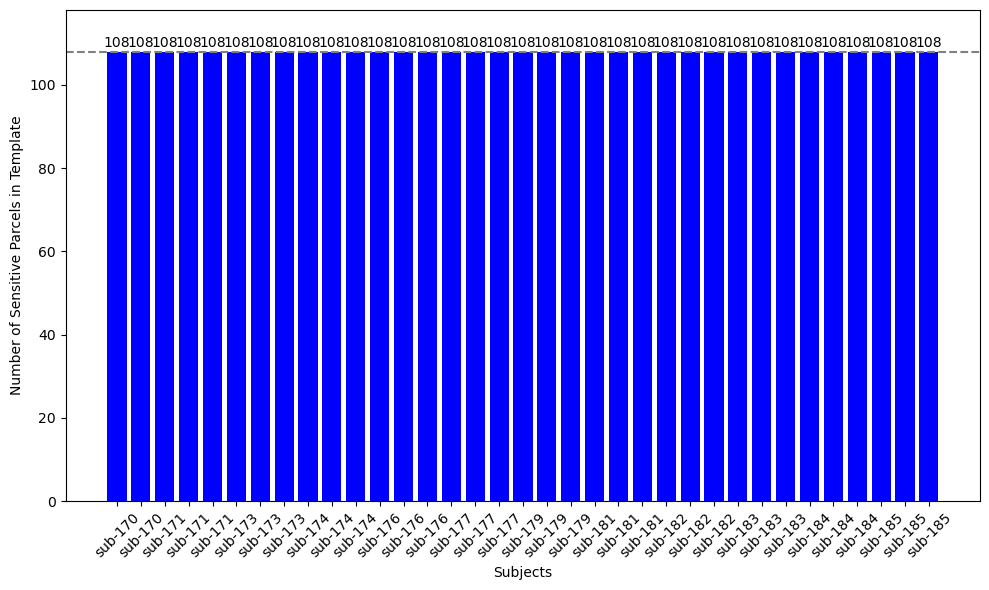

In [32]:
import matplotlib.pyplot as plt
# Plot as barplot the number of sensitive parcels in the template for each subject
files = list(file_sens_drop_parcels_dict.keys())
num_sensitive_in_template_list = []
for f in files:
    sensitive_parcels = file_sens_drop_parcels_dict[f]['sensitive_parcels']
    num_sensitive_in_template = len(set(sensitive_parcels) & set(template_sens_parcel_list))
    num_sensitive_in_template_list.append(num_sensitive_in_template)
plt.figure(figsize=(10, 6))
plt.bar(range(len(files)), num_sensitive_in_template_list, color='blue')
# print the number of sensitive parcels in the template for each subject on top of the bars
for i, num in enumerate(num_sensitive_in_template_list):    
    plt.text(i, num + 0.5, str(num), ha='center', va='bottom')
# plt.plot(range(len(files)), num_sensitive_in_template_list, color='red')
plt.xticks(range(len(files)), [f.split('/')[3].replace('.snirf', '') for f in files], rotation=45)
plt.xlabel('Subjects')
plt.ylabel('Number of Sensitive Parcels in Template')
plt.ylim(0, len(template_sens_parcel_list) + 10)
plt.axhline(y=len(template_sens_parcel_list), color='gray', linestyle='dashed')
# plt.legend()
# plt.title('Sensitive Parcels in Template for Each Subject')
plt.tight_layout()
plt.show()

In [37]:
rec.stim.head()

,onset,duration,value,trial_type
0,15.941632,10.0,1.0,Left
1,36.241408,10.0,1.0,Left
2,50.577408,10.0,1.0,Left
3,64.913408,10.0,1.0,Left
4,76.267520,10.0,1.0,Right


In [38]:
# load data for visualization
if DATASET_NAME == "BallSqueezingHD_modified":
    subject_name = 'sub-185'
    file_name = f'{subject_name}_task-BallSqueezing_run-3_nirs.pkl'
    file_to_plot = pre_processed_path / subject_name / file_name
    
elif DATASET_NAME == "FreshMotor":
    subject_name = 'sub-01'
    file_name = f'{subject_name}_task-FRESHMOTOR_run-left2s_nirs.pkl'
    file_to_plot = pre_processed_path / subject_name / file_name

elif DATASET_NAME == "BS_Laura":
    subject_name = 'sub-538'
    file_name = f'{subject_name}_task-BS_run-01_nirs.pkl'
    file_to_plot = pre_processed_path / subject_name / file_name
elif DATASET_NAME == "vfc_hd":
    subject_name = 'sub-12'
    file_name = f'{subject_name}_ses-01_task-WordStroop_run-01_nirs.pkl'
    file_to_plot = pre_processed_path / subject_name / file_name
elif DATASET_NAME == "Anderson_sparse":
    subject_name = 'sub-1'
    file_name = f'{subject_name}_ses-1_task-WordStroop_run-1_nirs.pkl'
    file_to_plot = pre_processed_path / subject_name / file_name    
    
# load data
with open(file_to_plot, 'rb') as handle:
    data = pickle.load(handle)

In [39]:
data['delta_conc']

<xarray.DataArray (time: 4216, parcel: 601, chromo: 2)> Size: 41MB
array([[[-2.97410722e-06, -1.12735791e-07],
        [ 3.87024705e-07,  7.19868158e-08],
        [ 3.96774860e-07,  1.11094598e-07],
        ...,
        [ 2.74454443e-11,  2.62990230e-11],
        [-1.60060735e-07, -8.18967126e-08],
        [ 2.99180554e-10,  3.89992195e-10]],

       [[-2.99602174e-06, -7.50421586e-08],
        [ 3.79346711e-07,  8.12907291e-08],
        [ 3.97927539e-07,  1.06497571e-07],
        ...,
        [ 3.02444825e-11,  2.47281595e-11],
        [-1.63078460e-07, -8.02420042e-08],
        [ 3.18825972e-10,  3.79155968e-10]],

       [[-3.01169932e-06, -3.71297075e-08],
        [ 3.70060944e-07,  9.00877312e-08],
        [ 3.96929413e-07,  1.02499864e-07],
        ...,
...
        ...,
        [-1.98830528e-11, -1.41811873e-12],
        [-2.36333294e-08,  2.54185536e-09],
        [-2.25427327e-10,  5.06707520e-11]],

       [[ 8.55452806e-07, -3.02340795e-08],
        [ 1.25741693e-08,  8.73248035e-08],
        [-6.21661843e-08,  9.89139925e-09],
        ...,
        [-2.18812878e-11, -4.61333356e-12],
        [-2.18778056e-08,  4.98469629e-09],
        [-2.50235650e-10,  3.32028560e-11]],

       [[ 8.85464836e-07, -2.32068759e-08],
        [-4.83377729e-09,  9.90987923e-08],
        [-6.04073745e-08,  1.75819257e-09],
        ...,
        [-2.35243335e-11, -8.07628721e-12],
        [-2.06104962e-08,  7.76907251e-09],
        [-2.71011195e-10,  1.27042242e-11]]], shape=(4216, 601, 2))
Coordinates:
  * chromo   (chromo) <U3 24B 'HbO' 'HbR'
  * time     (time) float64 34kB 12.96 13.07 13.19 13.3 ... 496.1 496.3 496.4
    samples  (time) int64 34kB 113 114 115 116 117 ... 4324 4325 4326 4327 4328
  * parcel   (parcel) object 5kB 'Background+FreeSurfer_Defined_Medial_Wall' ...

In [40]:
data.keys()

dict_keys(['conc_pcr', 'od_pcr1', 'delta_conc', 'rec_stim', 'sensitive_parcels'])

# Calculate block averages in optical density



In [41]:
data['conc_pcr']

Magnitude,[[[-0.0410481885582317 -0.28008768388768174 -0.38538585446821705 ... -0.17709477142457214 -0.226599671755866 -0.19647326162263168] [-0.0778392694045049 -0.27443277968159824 -0.4182850902715435 ... -0.15907801330925556 -0.20783946692375754 -0.13508583077856645] [0.03221556153832156 0.15406462128142406 0.12371423568225182 ... -0.4330899769230822 -0.4825389689933737 -0.2702809899136241] ... [-0.050078697187258686 0.14123209652385202 0.005239187802911355 ... 0.01246424951067305 0.03945526514757451 0.005979011325494152] [0.02966247491851115 -0.015623713955036936 -0.02320684151052073 ... 0.07482717696186034 -0.00021820610245078254 0.10595977277730936] [-0.035601708748519874 0.13838069719339305 -0.003729315756898083 ... 0.04100028865689492 0.09971592827710209 0.04632554450776369]] [[0.0667898476299671 -0.23242570357876266 -0.2065787114090152 ... 0.23465498312213384 0.18429473518515682 0.17573667339695298] [0.005481907236941828 -0.13280038004702513 -0.1351406294555602 ... -0.05890168252356656 -0.11181116835908617 -0.04008124401235451] [0.03742061893894606 0.07131927931363127 0.15866344900759224 ... 0.35230057693652844 0.31873232737011226 0.20003477384562457] ... [0.025808371153140157 0.00800416655818758 0.0509298929622924 ... 0.010361694088677872 0.014634294315204313 0.0036612365004740875] [0.05779917975608522 0.054086623968764 0.08461715191742183 ... -0.24402743831058363 -0.15409981163093214 0.010382873016766037] [0.023809623315561607 0.027957215956439265 0.07590234367246076 ... 0.057799510629233844 0.038080233933683066 0.026351525216197665]]]
Units,micromolar


In [42]:
rec['od_pcr1']

Magnitude,[[[0.0021276214875076706 -0.01404759517420678 -0.014628752485836317 ... 0.006958572808895447 0.004090502131899146 0.0042084952228568714] [-0.0009454557402879864 -0.009332621259798186 -0.011571701132806386 ... -0.0046968535877540355 -0.007511082538204165 -0.003596603361041264] [0.001823685609464305 0.004764762215148812 0.007553263013758643 ... 0.0069257124621795825 0.005003909246626364 0.0035933287146847443] ... [0.00027281245075783296 0.002444743981358417 0.002105085696555626 ... 0.0005998863758959952 0.0011762288287523294 0.0002356758982390199] [0.003074817697292828 0.002146013212680926 0.003378220453465059 ... -0.00960925925808516 -0.006868352612805546 0.002248764439346607] [0.0004110065377205992 0.003193736780502143 0.0029618138765657824 ... 0.0029150555696064086 0.0030144667186465884 0.0017447893285799717]] [[7.356024906984679e-05 -0.012250685659173604 -0.01475803371589365 ... -0.0006740250339792532 -0.0030112706871384116 -0.002315457828981661] [-0.0020007819889173695 -0.009732343377871195 -0.01364949027288139 ... -0.005323192756205572 -0.007568527964511368 -0.004345401618303206] [0.0014231932738233213 0.005039736515663304 0.005710864730294879 ... -0.005095567536278204 -0.006888358813302822 -0.0035054037941800982] ... [-0.0009028459692524967 0.003981122777707836 0.0010469896537018263 ... 0.0005228387918714248 0.0013323929889543498 0.00022754910741382017] [0.0020522862021414906 0.0006001251945297676 0.0009765013821737218 ... -0.0025756596889194476 -0.00307130081318434 0.0034314742635414047] [-0.0005445108080922576 0.004255481821049508 0.0012460109843600246 ... 0.002139787912445951 0.003384813538474109 0.0017262285087966598]]]
Units,dimensionless


Blockaverage od_pcr1

In [43]:
# import matplotlib.pyplot as p

# # segment data into epochs
# if DATASET_NAME in ["BallSqueezingHD_modified", "BS_Laura"]:
#     epochs = rec['od_pcr1'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["left", "right"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
# elif DATASET_NAME == "FreshMotor":
#     epochs = rec['od_pcr1'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["right"],  # select left/right events
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
# elif DATASET_NAME in ["vfc_hd", "Anderson_sparse"]:
#     epochs = rec['od_pcr1'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["WordCongruent", "WordIncongruent"],
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
    
# # calculate baseline
# baseline = epochs.sel(reltime=(epochs.reltime < 0)).mean("reltime")

# # subtract baseline
# epochs_blcorrected = epochs - baseline

# # group trials by trial_type. For each group individually average the epoch dimension
# blockaverage_od_pcr1 = epochs_blcorrected.groupby("trial_type").mean("epoch")

In [44]:
# from IPython.display import Image
# def display_image(fname : str):
#     display(Image(data=open(fname,'rb').read(), format='png'))

In [45]:
# results_path_prefix = f'results/{subset_type}/{DATASET_NAME}/{subject_name}'
# os.makedirs(results_path_prefix, exist_ok=True)

In [46]:
# # Plot block averages. Please ignore errors if the plot is too small in the HD case

# filename = f"results/{subset_type}/{DATASET_NAME}/blockaverage_channel_space_{subset_type}.png"

# noPlts2 = int(np.ceil(np.sqrt(len(blockaverage_od_pcr1.channel))))
# f,ax = p.subplots(noPlts2,noPlts2, figsize=(12,10))
# ax = ax.flatten()
# for i_ch, ch in enumerate(blockaverage_od_pcr1.channel):
#     for ls, trial_type in zip(["-", "--"], blockaverage_od_pcr1.trial_type):
#         ax[i_ch].plot(blockaverage_od_pcr1.reltime, blockaverage_od_pcr1.sel(wavelength=760, trial_type=trial_type, channel=ch), "r", lw=2, ls=ls)
#         ax[i_ch].plot(blockaverage_od_pcr1.reltime, blockaverage_od_pcr1.sel(wavelength=850, trial_type=trial_type, channel=ch), "b", lw=2, ls=ls)

#     ax[i_ch].grid(1)
#     ax[i_ch].set_title(ch.values)
#     ax[i_ch].set_ylim(-.02, .02)
#     ax[i_ch].set_axis_off()
#     ax[i_ch].axhline(0, c="k")
#     ax[i_ch].axvline(0, c="k")

# # p.suptitle("760nm: r | 850nm: b | left: - | right: --")
# p.suptitle("HbO: r | HbR: b | left: - | right: --")

# p.tight_layout()
# p.savefig(filename)

In [47]:
def match_landmark_labels(rec):
    subject_nasion_mask = rec.geo3d['label'].data == 'NASION'

    new_labels = rec.geo3d['label'].data.copy()
    new_labels[subject_nasion_mask] = 'Nz'

    # Create new geo3d with updated labels
    rec.geo3d = rec.geo3d.assign_coords(label=new_labels)
    # print(rec.geo3d['label'].data)

    return rec

In [48]:
rec = match_landmark_labels(rec)

In [49]:
# # Viz reconstruction on Channel Space
# import cedalion.vis.anatomy
# filename_scalp = f"results/{subset_type}/{DATASET_NAME}/scalp_plot_ts_{subset_type}.png"

# # data_ts = blockaverage_od_pcr1.sel(wavelength=850, trial_type="right")
# data_ts = blockaverage_od_pcr1.sel(wavelength=850, trial_type="WordCongruent")
# # scalp_plot_gif expects the time dimension to be named 'time'
# data_ts = data_ts.rename({"reltime": "time"})

# # call plot function 
# cedalion.vis.anatomy.scalp_plot_gif(
#     data_ts,
#     rec.geo3d,
#     filename=filename_scalp,
#     time_range=(-5, 30, 0.5) * units.s,
#     scl=(-0.01, 0.01),
#     fps=6,
#     optode_size=6,
#     optode_labels=True,
#     str_title="OD 850 nm",
# )
# display_image(f"{filename_scalp}.gif")

Blockaverage_delta_conc

In [50]:
# if DATASET_NAME == "BallSqueezingHD_modified" or DATASET_NAME == "BS_Laura":
#     epochs = data['delta_conc'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["left", "right"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
# elif DATASET_NAME == "FreshMotor":
#     # segment data into epochs
#     epochs = data['delta_conc'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["right"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )
    
# elif DATASET_NAME in ["vfc_hd", "Anderson_sparse"]:
#     # segment data into epochs
#     epochs = data['delta_conc'].cd.to_epochs(
#         rec.stim,  # stimulus dataframe
#         ["WordCongruent", "WordIncongruent"],  # select fingertapping events, discard others
#         before=2 * units.s,  # seconds before stimulus
#         after=10 * units.s,  # seconds after stimulus
#     )    

# # calculate baseline
# baseline = epochs.sel(reltime=(epochs.reltime < 0)).mean("reltime")

# # subtract baseline
# epochs_blcorrected = epochs - baseline

# # group trials by trial_type. For each group individually average the epoch dimension
# blockaverage_delta_conc = epochs_blcorrected.groupby("trial_type").mean("epoch")

In [51]:
# vertex_parcels = head_icbm152.brain.vertex_coords['parcel']
# vertex_parcels = np.array(vertex_parcels)

# parcel_index = blockaverage_delta_conc.get_index("parcel")  # pandas index
# vertex_parcel_idx = parcel_index.get_indexer(vertex_parcels)

# parcel_data = blockaverage_delta_conc.values  # shape (2, 107, 601, 2)

# # Broadcast using integer indexing on axis=2 (parcel axis)
# vertex_activity = parcel_data[:, :, vertex_parcel_idx, :]

# n_vertices = len(vertex_parcel_idx)

# vertex_da = xr.DataArray(
#     vertex_activity,
#     dims=("trial_type", "reltime", "vertex", "chromo"),
#     coords=dict(
#         trial_type=blockaverage_delta_conc.trial_type,
#         reltime=blockaverage_delta_conc.reltime,
#         chromo=blockaverage_delta_conc.chromo,

#         # vertex index
#         vertex=np.arange(n_vertices),

#         # parcel label of each vertex
#         parcel_of_vertex=("vertex", vertex_parcels),

#         # NEW: is_brain flag
#         is_brain=("vertex", np.ones(n_vertices, dtype=bool))
#     )
# )

# vertex_da.shape

In [52]:
# filename_multiview = f'{results_path_prefix}/image_recon_multiview_{subset_type}'

# # prepare data
# # X_ts = vertex_da.sel(trial_type="right").rename({"reltime": "time"})
# X_ts = vertex_da.sel(trial_type="WordCongruent").rename({"reltime": "time"})
# X_ts = X_ts.transpose("vertex", "chromo", "time")

# scl = np.percentile(np.abs(X_ts.sel(chromo='HbO')).pint.dequantify(), 99)
# clim = (-scl,scl)

# cedalion.vis.anatomy.image_recon_multi_view(
#     X_ts,  # time series data; can be 2D (static) or 3D (dynamic)
#     head_icbm152,
#     cmap='seismic',
#     clim=clim,
#     view_type='hbo_brain',
#     title_str='HbO / µM',
#     filename=filename_multiview,
#     SAVE=True,
#     time_range=(-2,10,0.5)*units.s,
#     fps=6,
#     geo3d_plot = None, #  geo3d_plot
#     wdw_size = (1024, 768)
# )
# display_image(filename_multiview+'.gif')

# Segmentation

In [53]:
pre_processed_path

PosixPath('datasets/pre_processed/base/BallSqueezingHD_modified/full')

In [54]:
processed_path = Path(f'datasets/processed/{DATASET_NAME}/{subset_type}')
processed_path.mkdir(parents=True, exist_ok=True)
processed_path

PosixPath('datasets/processed/BallSqueezingHD_modified/full')

In [55]:
# load (all) parcel files
preproc_files_path = str(pre_processed_path / 'sub-*' / '*.pkl')
proc_pkl_files = glob.glob(preproc_files_path)

len(proc_pkl_files), proc_pkl_files[:2]

(35,
 ['datasets/pre_processed/base/BallSqueezingHD_modified/full/sub-176/sub-176_task-BallSqueezing_run-1_nirs.pkl',
  'datasets/pre_processed/base/BallSqueezingHD_modified/full/sub-176/sub-176_task-BallSqueezing_run-3_nirs.pkl'])

In [56]:
min_len_sens_parcels = float('inf')
min_len_i = None

for i in range(len(proc_pkl_files)):
    with open(proc_pkl_files[i], 'rb') as handle:
        data_pickle = pickle.load(handle)
        delta_brain = data_pickle['delta_conc']
        sensitive_parcels = data_pickle['sensitive_parcels']
        print(f"File {i}: {len(sensitive_parcels)} sensitive parcels")
        if len(sensitive_parcels) < min_len_sens_parcels:
            min_len_sens_parcels = len(sensitive_parcels)
            min_len_i = i
            
        # also check how many of the sensitive parcels are motor are
        motor_labels = [l for l in sensitive_parcels if l.startswith("SomMot")]
        print(f"File {i}: {len(motor_labels)} motor labels")
        print("-"*50)
            
min_len_i, min_len_sens_parcels

File 0: 108 sensitive parcels
File 0: 45 motor labels
--------------------------------------------------
File 1: 108 sensitive parcels
File 1: 45 motor labels
--------------------------------------------------
File 2: 108 sensitive parcels
File 2: 45 motor labels
--------------------------------------------------
File 3: 108 sensitive parcels
File 3: 45 motor labels
--------------------------------------------------
File 4: 108 sensitive parcels
File 4: 45 motor labels
--------------------------------------------------
File 5: 108 sensitive parcels
File 5: 45 motor labels
--------------------------------------------------
File 6: 108 sensitive parcels
File 6: 45 motor labels
--------------------------------------------------
File 7: 108 sensitive parcels
File 7: 45 motor labels
--------------------------------------------------
File 8: 108 sensitive parcels
File 8: 45 motor labels
--------------------------------------------------
File 9: 108 sensitive parcels
File 9: 45 motor labels
-

(0, 108)

In [57]:
with open(proc_pkl_files[7], 'rb') as handle:
    data_pickle = pickle.load(handle)
    delta_brain = data_pickle['delta_conc']
    sensitive_parcels = data_pickle['sensitive_parcels']
len(sensitive_parcels)

108

In [58]:
from collections import Counter

# Gather all fs_mean values from all files
fs_list = []
for file in proc_pkl_files:
    with open(file, 'rb') as handle:
        data_pickle = pickle.load(handle)
    delta_brain = data_pickle['delta_conc']
    
    dt = np.diff(delta_brain.time.data)
    fs_mean = float(1.0 / np.mean(dt))
    
    fs_list.append(fs_mean)

fs_counts = Counter(fs_list)
len (proc_pkl_files), fs_counts

(35, Counter({8.719308035714286: 35}))

In [59]:
with open(file, 'rb') as handle:
    data_pickle = pickle.load(handle)

delta_brain = data_pickle['delta_conc']
sensitive_parcels = data_pickle['sensitive_parcels']
rec_stim = data_pickle['rec_stim']

delta_brain.time.data

array([ 12.500992,  12.61568 ,  12.730368, ..., 481.918976, 482.033664,
       482.148352], shape=(4096,))

In [60]:
delta_brain.sel(parcel=template_sens_parcel_list).shape

(4096, 108, 2)

In [ ]:
use_channel_space = False

## Parcel space

In [ ]:
if not use_channel_space:
    baseline_duration = 2.5  # in seconds
    n_shifts = 9
    duration = 10  # in seconds
    post_padding = 5  # in seconds
    extract_rest_segments = DATASET_NAME in ["vfc_hd", "Anderson_sparse"]
    resample = False
    delta_range = (-2.5, 2.5)

    if DATASET_NAME == "BallSqueezingHD_modified":
        n_timepoints = 87 # 244 # 174 # fixed length after shifting
    elif DATASET_NAME == "BS_Laura":
        n_timepoints = 87 # 244 # 174 # fixed length after shifting
        resample = True
    elif DATASET_NAME == "vfc_hd":
        n_timepoints = 174 # fixed length after shifting

    if DATASET_NAME == "FreshMotor":
        delta_range = (-2.0, 0.0)

    start_shift = np.linspace(*delta_range, n_shifts)
        
    for file in proc_pkl_files:
        with open(file, 'rb') as handle:
            data_pickle = pickle.load(handle)
        
        rec_stim = data_pickle['rec_stim']
        delta_brain = data_pickle['delta_conc'] # parcel space data
        sensitive_parcels = data_pickle['sensitive_parcels']
        
        # IMPORTANT: select only parcels in the common template
        delta_brain = delta_brain.sel(parcel=template_sens_parcel_list)
        
        # ---- NEW: Resampling ---- use for Laura, (and ??)
        if resample:
            if DATASET_NAME == "BS_Laura":
                target_fs = 8.7 # 24.4 # 8.98876404494382  # From BSQ-HD
            dt = 1.0 / target_fs
            t0 = float(delta_brain.time.min())
            t1 = float(delta_brain.time.max())
            new_time = np.arange(t0, t1 + 1e-9, dt)
            delta_brain = delta_brain.interp(time=new_time)
        # -------------------------
        
        # Process event segments
        i = 0
        for index, row in rec_stim.iterrows():
            # Binary labeling: pool word conditions into "task" label
            trial_type_clean = row["trial_type"].lower()

            if "word" in trial_type_clean:
                label = f"{trial_type_clean}_task"
            else:
                label = trial_type_clean
                
            for s in start_shift:
                start_time = row["onset"] + s
                end_time = start_time + duration + post_padding # in seconds
                
                baseline = delta_brain.sel(
                    time=slice(row["onset"] - baseline_duration, row["onset"])
                ).mean("time")
                
                # Then, trimming is easy with `.sel()`:
                x = delta_brain.sel(time=slice(start_time, end_time)) - baseline
                x = x.isel(time=slice(0, n_timepoints))
                
                # new check
                # print(x.sizes["time"], " timepoints")
                if x.sizes["time"] < n_timepoints:
                    print(f"Skipping segment for file {os.path.basename(file)} at trial {i} due to insufficient length: {x.sizes['time']} < {n_timepoints}")
                    # continue  # skip short segment
                
                x = x.transpose("parcel", "chromo", "time")
                del x.time.attrs['units']

                if not os.path.exists(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path)))):
                    os.makedirs(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path))))
                if s == 0:
                    x.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+"_test.nc"))
                    i += 1
                else:
                    x.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+".nc"))
                    i += 1

        if extract_rest_segments:
            # --- REST-STATE SEGMENT EXTRACTION ---
            # Rest segments: start at event_onset + 15s, end at next_event_onset - 5s
            # Extracted with 0.5s sliding window, 10s duration each
            recording_start = float(delta_brain.time.values[0])
            recording_end = float(delta_brain.time.values[-1])
            segment_length_sec = duration  # 10 seconds
            rest_label = "rest"
            step_sec = 0.25  # sliding window step
            rest_segment_count = 0
            
            # Process rest intervals between consecutive events
            for idx in range(len(rec_stim)):
                current_onset = rec_stim.iloc[idx]["onset"]
                
                # Rest interval: [event_onset + 15s, next_event_onset - 5s]
                rest_start = current_onset + 15.0
                
                if idx + 1 < len(rec_stim):
                    next_onset = rec_stim.iloc[idx + 1]["onset"]
                    rest_end = next_onset - 5.0
                else:
                    rest_end = recording_end
                
                interval_length = rest_end - rest_start
                
                # Check if interval is long enough for at least one segment
                if interval_length < segment_length_sec:
                    print(f"  Skipping rest interval {idx}: [{rest_start:.1f}s - {rest_end:.1f}s] (length: {interval_length:.1f}s < {segment_length_sec}s)")
                    continue
                
                print(f"  Rest interval {idx}: [{rest_start:.1f}s - {rest_end:.1f}s] (length: {interval_length:.1f}s)")
                
                # First pass: collect valid rest segment starts in this interval
                t = rest_start
                valid_segment_starts = []
                
                while t + segment_length_sec <= rest_end:
                    baseline_start = max(t - baseline_duration, recording_start)
                    baseline_rest = delta_brain.sel(time=slice(baseline_start, t)).mean("time")
                    x_rest = delta_brain.sel(time=slice(t, t + segment_length_sec)) - baseline_rest
                    x_rest = x_rest.isel(time=slice(0, n_timepoints))
                    
                    # Skip if segment is too short
                    if x_rest.sizes["time"] < n_timepoints:
                        print(f"    Skipping rest segment at t={t:.1f}s (insufficient samples: {x_rest.sizes['time']} < {n_timepoints})")
                        t += step_sec
                        continue
                    
                    valid_segment_starts.append(t)
                    t += step_sec
                
                if len(valid_segment_starts) == 0:
                    continue
                
                # Select the segment centered closest to interval midpoint as test
                interval_midpoint = (rest_start + rest_end) / 2.0
                segment_centers = np.array(valid_segment_starts) + (segment_length_sec / 2.0)
                test_segment_idx = int(np.argmin(np.abs(segment_centers - interval_midpoint)))
                
                interval_segments = 0
                for seg_idx, t_start in enumerate(valid_segment_starts):
                    baseline_start = max(t_start - baseline_duration, recording_start)
                    baseline_rest = delta_brain.sel(time=slice(baseline_start, t_start)).mean("time")
                    x_rest = delta_brain.sel(time=slice(t_start, t_start + segment_length_sec)) - baseline_rest
                    x_rest = x_rest.isel(time=slice(0, n_timepoints))
                    x_rest = x_rest.transpose("parcel", "chromo", "time")
                    del x_rest.time.attrs['units']
                    
                    is_test_segment = seg_idx == test_segment_idx
                    rest_suffix = "_test.nc" if is_test_segment else ".nc"
                    rest_filename = file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", f"_{rest_label}_{rest_segment_count}{rest_suffix}")
                    x_rest.to_netcdf(rest_filename)
                    rest_segment_count += 1
                    interval_segments += 1
                
                print(f"  Extracted {interval_segments} rest segments from interval {idx} (middle segment index {test_segment_idx} saved as _test.nc)")
        
            print(f"Total rest segments extracted: {rest_segment_count}")

        print("finished processing file: ", os.path.basename(file).replace(".pkl",".npy"))

    print('\n--- Done!---')

In [ ]:
if extract_rest_segments:
    from collections import defaultdict
    import pandas as pd
    segmented_files = glob.glob(str(processed_path / 'sub-*' / '*.nc'))

    subject_label_counts = defaultdict(lambda: defaultdict(int))

    for file_path in segmented_files:
        filename = os.path.basename(file_path)
        subject = os.path.basename(os.path.dirname(file_path))
        
        if '_task_' in filename:
            label = 'task'
        elif '_rest_' in filename:
            label = 'rest'
        else:
            label = 'unknown'
        
        subject_label_counts[subject][label] += 1

    data_for_df = []
    for subject in sorted(subject_label_counts.keys()):
        counts = subject_label_counts[subject]
        data_for_df.append({
            'Subject': subject,
            'Task': counts.get('task', 0),
            'Rest': counts.get('rest', 0),
            'Total': counts.get('task', 0) + counts.get('rest', 0)
        })

    df_counts = pd.DataFrame(data_for_df)

    print(df_counts.to_string(index=False))

    print("="*40)
    print(f"Total subjects: {len(df_counts)}")
    print(f"Total task segments: {df_counts['Task'].sum()}")
    print(f"Total rest segments: {df_counts['Rest'].sum()}")
    print(f"Total segments: {df_counts['Total'].sum()}")
    print(f"\nClass balance: Task={df_counts['Task'].sum()}, Rest={df_counts['Rest'].sum()}")
    print(f"Task/Rest ratio: {df_counts['Task'].sum() / df_counts['Rest'].sum():.2f}" if df_counts['Rest'].sum() > 0 else "Task/Rest ratio: N/A")

In [ ]:
if extract_rest_segments:

    test_files = sorted(processed_path.rglob("*_test.nc"))

    counts = {"task": 0, "rest": 0}
    for f in test_files:
        name = f.name.lower()
        if "_rest_" in name:
            counts["rest"] += 1
        else:
            counts["task"] += 1

    df_test_counts = pd.DataFrame([
        {"Label": "task", "_test_files": counts["task"]},
        {"Label": "rest", "_test_files": counts["rest"]},
    ])

    display(df_test_counts)
    print(f"Total _test files: {len(test_files)}")


### Channel space

In [ ]:
if use_channel_space:
    
    baseline_duration = 2.5  # in seconds
    n_shifts = 9
    duration = 10  # in seconds
    post_padding = 5  # in seconds
    extract_rest_segments = DATASET_NAME in ["vfc_hd", "Anderson_sparse"]
    resample = False
    delta_range = (-2.5, 2.5)
    
    if DATASET_NAME == "BallSqueezingHD_modified":
        n_timepoints = 87 # 244 # 174 # fixed length after shifting
    elif DATASET_NAME == "BS_Laura":
        n_timepoints = 87 # 244 # 174 # fixed length after shifting
        resample = True
    elif DATASET_NAME == "vfc_hd":
        n_timepoints = 174 # fixed length after shifting
        
    if DATASET_NAME == "FreshMotor":
        delta_range = (-2.0, 0.0)
    
    start_shift = np.linspace(*delta_range, n_shifts)

    for file in proc_pkl_files:
        with open(file, 'rb') as handle:
            data_pickle = pickle.load(handle)
        
        rec_stim = data_pickle['rec_stim']
        conc_pcr = data_pickle['conc_pcr'] # channel space data
        
        if resample:
            if DATASET_NAME == "BS_Laura":
                target_fs = 8.7 # 24.4 # 8.98876404494382  # From BSQ-HD
            dt = 1.0 / target_fs
            t0 = float(conc_pcr.time.min())
            t1 = float(conc_pcr.time.max())
            new_time = np.arange(t0, t1 + 1e-9, dt)
            conc_pcr = conc_pcr.interp(time=new_time)
        
        i = 0
        for index, row in rec_stim.iterrows():
            trial_type_clean = row["trial_type"].lower()
            
            if "word" in trial_type_clean:
                label = f"{trial_type_clean}_task"
            else:
                label = trial_type_clean
            
            for s in start_shift:
                start_time = row["onset"] + s
                end_time = start_time + duration + post_padding # in seconds
                
                # channel space baseline
                baseline_conc_pcr = conc_pcr.sel(
                    time=slice(row["onset"] - baseline_duration, row["onset"])
                ).mean("time")
            
                # channel space segment
                x_channel = conc_pcr.sel(time=slice(start_time, end_time)) - baseline_conc_pcr
                x_channel = x_channel.isel(time=slice(0, n_timepoints))
                x_channel = x_channel.transpose("channel", "chromo", "time")

                # print(x_channel.shape)
                del x_channel.time.attrs['units']
                
                if not os.path.exists(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path)))):
                    os.makedirs(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path))))
                if s == 0:
                    x_channel.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+"_test.nc"))
                    i += 1
                else:
                    x_channel.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+".nc"))
                    i += 1

        print("finished processing file: ", os.path.basename(file).replace(".pkl",".npy"))
    print('--- Done!---')            

In [ ]:
# load a specific .nc file
file_to_load = "datasets/processed/Anderson_sparse/sub-1/sub-1_ses-1_task-WordStroop_run-1_nirs_wordcongruent_0.nc"
ds = xr.load_dataset(file_to_load)
ds

file_to_load = "datasets/processed/vfc_hd/sub-01/sub-01_ses-02_task-WordStroop_run-01_nirs_wordcongruent_0.nc"
ds = xr.load_dataset(file_to_load)
ds



### Old appraoch using event files and freq0.5

FreshMotor

- parcel space: (parcel: 110, chromo: 2, time: 87)
- channel space: (time: 87, channel: 68, chromo: 2)

---
BallSqueezing

- parcel space: (parcel: 110, chromo: 2, time: 87)
- channel space: (channel: 100, chromo: 2, time: 87)


In [ ]:
# FRESHMOTOR dataset
# load one processed nc file
filename = 'datasets/processed/FreshMotor/sub-01/sub-01_task-FRESHMOTOR_run-left2s_nirs_left_0.nc'
data = xr.load_dataset(filename)
    
# extract np array from xarray and remove first dimension
# data.to_array().squeeze().transpose("channel", "chromo", "time")
data

In [ ]:
type(data)
getattr(data, "dims", None)
[data[v].dims for v in data.data_vars]  # if Dataset



# Outdated approach

In [ ]:
baseline_duration = 2.5  # in seconds
n_shifts = 9
duration = 10  # in seconds
post_padding = 5  # in seconds
n_timepoints = 87  # fixed length after shifting

if DATASET_NAME == "BallSqueezingHD_modified":
    delta_range = (-2.5, 2.5)
elif DATASET_NAME == "FreshMotor":
    delta_range = (-2.0, 0.0)
start_shift = np.linspace(*delta_range, n_shifts)






label_dict = {'right':1, 'left':2}  
subject_to_rec = {}            
INDEX = 0     
freq_dir = processed_path / f'frq{0.5}'
freq_dir.mkdir(exist_ok=True)       
for file in proc_pkl_files:
    with open(file, 'rb') as handle:
        data_pickle = pickle.load(handle)
    
    delta_brain = data_pickle['delta_conc']
    sensitive_parcels = data_pickle['sensitive_parcels']
    rec_stim = data_pickle['rec_stim']

    # Align subject-specific parcels to a common parcel template (zero-pad missing parcels)
    # delta_brain = delta_brain.sel(parcel=sensitive_parcels).reindex(parcel=PARCEL_TEMPLATE, fill_value=0)
    delta_brain = delta_brain.sel(parcel=template_sens_parcel_list)

    i = 0
    
    
    
    
    # ------
    SUB = PureWindowsPath(file).parts[-2]
    if SUB not in subject_to_rec:
        subject_to_rec[SUB] = []
    try:
        sub_dir = Path(freq_dir) / SUB
        sub_dir.mkdir(parents=True, exist_ok=True)
    except FileExistsError:
        pass
    # ------

    for index, row in rec_stim.iterrows():
        label = row["trial_type"].lower()
        for s in start_shift:
            start_time = row["onset"] + s
            end_time = start_time + duration + post_padding # in seconds
            baseline = delta_brain.sel(
                time=slice(row["onset"] - baseline_duration, row["onset"])
            ).mean("time")
            
            # Then, trimming is easy with `.sel()`:
            x = delta_brain.sel(time=slice(start_time, end_time)) - baseline
            x = x.isel(time=slice(0, n_timepoints))
            x = x.transpose("parcel", "chromo", "time")
            del x.time.attrs['units']

            data = {
                'xt': x,
                'file': file,
                'class': label_dict[label],
            }

            # -----
            # save events
            filename = r'{}/{}/event_{}_delta{:+.2f}_{}.pkl'.format(freq_dir, SUB, 'aug' if s != 0.0 else 'orig', s, INDEX)
            subject_to_rec[SUB].append(filename)
            INDEX += 1
            # -----
            
            
            # if not os.path.exists(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path)))):
            #     os.makedirs(os.path.dirname(file.replace(str(pre_processed_path), str(processed_path))))
            # if s == 0:
            #     x.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+"_test.nc"))
            #     i += 1
            # else:
            #     x.to_netcdf(file.replace(str(pre_processed_path), str(processed_path)).replace(".pkl", "_" + label + "_"+str(i)+".nc"))
            #     i += 1
            with open(filename, 'wb') as handle:
                pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)
                
with open('{}/meta_event_{}.pkl'.format(freq_dir, 0.5), 'wb') as handle:
    pickle.dump(subject_to_rec, handle, protocol=pickle.HIGHEST_PROTOCOL)
print('--- Done!---')            
    # print("finished processing file: ", os.path.basename(file).replace(".pkl",".npy"))

In [ ]:
events = "datasets/processed/{}/frq{}/meta_event_{}.pkl"
    
meta_events = []

with open(events.format(DATASET_NAME, 0.5, 0.5), 'rb') as handle:
    meta = pickle.load(handle)
meta_events.append(meta)


if DATASET_NAME == "BallSqueezingHD_modified":
    session_to_files = {'run-1':[],
                        'run-2':[],
                        'run-3':[]}
    
elif DATASET_NAME == "FreshMotor":    
    session_to_files = {'run-left2s':[],
                        'run-right2s':[],
                        'run-left3s':[],
                        'run-right3s':[]}

files_to_session = {}
for meta_event in meta_events:
    for sub in meta_event:
        for file in meta_event[sub]:
            meta = None
            with open(file, 'rb') as handle:
                meta = pickle.load(handle) 
            
            run = meta['file'].split('_')[-2]
            files_to_session[file] = run
            session_to_files[run].append(file)

for run in session_to_files:
    print(run, len(session_to_files[run]))

# this will save the mapping of files to sessions used for LOSO
with open(f'datasets/processed/{DATASET_NAME}/files_to_sessions.pkl', 'wb') as handle:
    pickle.dump(files_to_session, handle, protocol=pickle.HIGHEST_PROTOCOL)     
print("Saved files_to_sessions.pkl")